# Bandit Problem

In [15]:
# imports
from bandits import Bandit
import random
# Include your imports here, if any are used. 
import numpy as np 
import matplotlib.pyplot as plt 

A bandit is one option (or “arm”) you can choose, where the reward you get is uncertain and must be learned by trying it out.
In multi-armed bandits, you repeatedly pick among several such uncertain options to find which one pays best.

A list of ten bandit objects initialized in the list...

In [16]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]

To generate reward from that bandit, use the pullLever() command

In [17]:
bandits[0].pullLever()

1.0117907192719073

## Greedy algorithm Implementation

In [18]:
def run_greedy():
    N=np.zeros(10)
    Q=np.zeros(10)
    rewards=[]
    for x in range(1000):
        max_index=np.argmax(Q)
        reward=bandits[max_index].pullLever()
        rewards.append(reward)
        N[max_index]+=1
        Q[max_index]=Q[max_index]+(reward-Q[max_index])/N[max_index]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases. and display that image below.

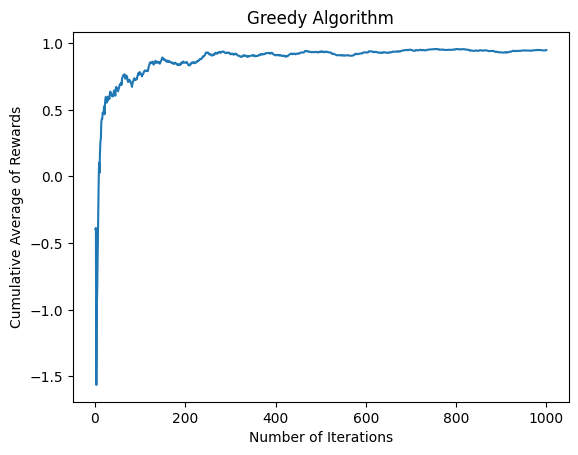

In [19]:
rewards=run_greedy()
x=np.arange(1,1001)
cumulative=np.cumsum(rewards)
y=cumulative/x
plt.plot(x,y)
plt.xlabel("Number of Iterations")
plt.ylabel("Cumulative Average of Rewards")
plt.title("Greedy Algorithm")
plt.show()

## $\epsilon$-greedy Algorithm

In [20]:
def run_epsilon_greedy(epsilon):
    N=np.zeros(10)
    Q=np.zeros(10)
    rewards=[]
    for x in range(1000):
        if random.random()>epsilon:
            max_index=np.argmax(Q)
        else:
            max_index=random.randint(0, 9)
        reward=bandits[max_index].pullLever()
        rewards.append(reward)
        N[max_index]=N[max_index]+1
        Q[max_index]=Q[max_index]+(reward-Q[max_index])/N[max_index]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

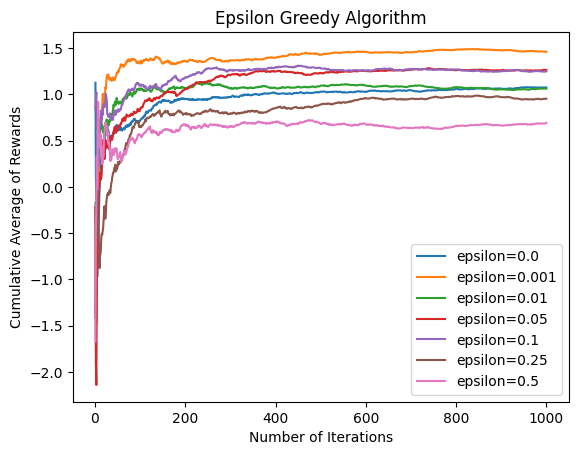

In [21]:
x=np.arange(1,1001)
epsilon_values=[0.0,0.001,0.01,0.05,0.1,0.25,0.5]
for epsilon in epsilon_values:
    rewards = run_epsilon_greedy(epsilon)
    cumulative = np.cumsum(rewards)
    y=cumulative/x
    plt.plot(x, y, label =f"epsilon={epsilon}")
plt.xlabel("Number of Iterations")
plt.ylabel("Cumulative Average of Rewards")
plt.title("Epsilon Greedy Algorithm")
plt.legend()
plt.show()

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

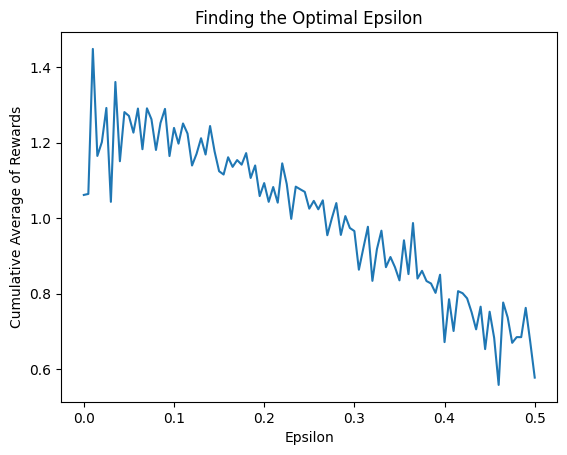

The optimal epsilon is:  0.01


In [22]:
x=np.linspace(0,0.5,101)
y=[]
for epsilon in x:
    rewards=run_epsilon_greedy(epsilon)
    y.append(np.mean(rewards))
plt.plot(x,y)
plt.xlabel("Epsilon")
plt.ylabel("Cumulative Average of Rewards")
plt.title("Finding the Optimal Epsilon")
plt.show()
print("The optimal epsilon is: ", x[np.argmax(y)])

## Optimistic Initial Values

In [23]:
def run_optimistic_greedy():
    N=np.zeros(10)
    Q=np.ones(10)*10
    rewards=[]
    for x in range(1000):
        max_index=np.argmax(Q)
        reward=bandits[max_index].pullLever()
        rewards.append(reward)
        N[max_index]=N[max_index]+1
        Q[max_index]=Q[max_index]+(reward-Q[max_index])/N[max_index]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$ and try to compare which is better.

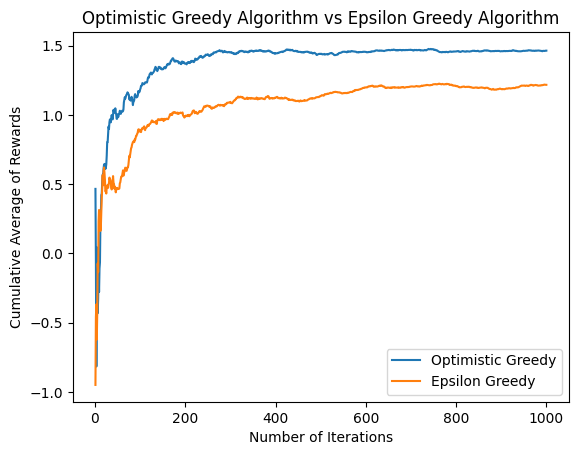

In [24]:
x=np.arange(1,1001)
rewards=run_optimistic_greedy()
cumulative = np.cumsum(rewards)
y=cumulative/x
rewards2=run_epsilon_greedy(0.1)
cumulative2 = np.cumsum(rewards2)
y2=cumulative2/x
plt.plot(x,y,label="Optimistic Greedy")
plt.plot(x,y2,label="Epsilon Greedy")
plt.xlabel("Number of Iterations")
plt.ylabel("Cumulative Average of Rewards")
plt.title("Optimistic Greedy Algorithm vs Epsilon Greedy Algorithm")
plt.legend()
plt.show()

## Upper Confidence Bound (UCB)

In [25]:
def run_ucb(c):
    N=np.zeros(10)
    Q=np.zeros(10)
    rewards=[]
    for x in range(1,1001):
        ucb=np.zeros(10)
        for i in range(10):
            if N[i]==0:
                ucb[i]=float('inf')
            else:
                ucb[i]=Q[i]+c*np.sqrt(np.log(x)/N[i])
        max_index=np.argmax(ucb)
        reward=bandits[max_index].pullLever()
        rewards.append(reward)
        N[max_index]=N[max_index]+1
        Q[max_index]=Q[max_index]+(reward-Q[max_index])/N[max_index]
    return rewards

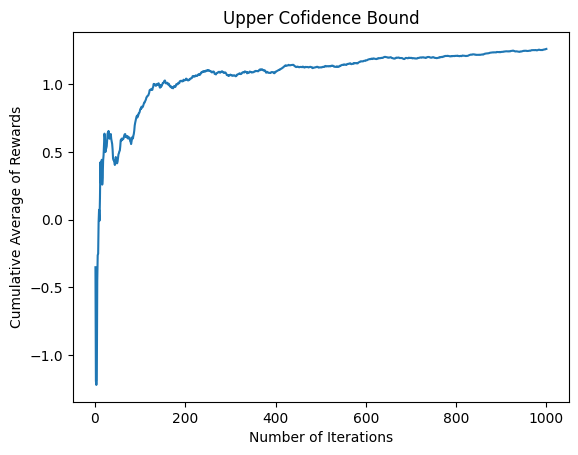

In [26]:
rewards=run_ucb(2)
x=np.arange(1,1001)
cumulative = np.cumsum(rewards)
y=cumulative/x
plt.plot(x,y)
plt.xlabel("Number of Iterations")
plt.ylabel("Cumulative Average of Rewards")
plt.title("Upper Cofidence Bound")
plt.show()